In [31]:
import os

import IPython.display as ipd
import keras
import librosa
import matplotlib.pyplot as plt 
import numpy as np
import random
import seaborn as sns
import tensorflow as tf

from keras.models import Sequential
from keras.layers import BatchNormalization, Conv2D, Dense, Dropout, Flatten, MaxPool2D, Reshape

In [32]:
# Using the standardized 2-second truncated audio files

train_real_directory = "/kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/training/real"
train_fake_directory = "/kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/training/fake"

validation_real_directory = "/kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/validation/real"
validation_fake_directory = "/kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/validation/fake"

test_real_directory = "/kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/testing/real"
test_fake_directory = "/kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/testing/fake"

In [33]:
# Get waveform (.wav) audio files

train_real_audio = [os.path.join(train_real_directory, file) for file in os.listdir(train_real_directory) if file.endswith('.wav')]
train_fake_audio = [os.path.join(train_fake_directory, file) for file in os.listdir(train_fake_directory) if file.endswith('.wav')]

validation_real_audio = [os.path.join(validation_real_directory, file) for file in os.listdir(validation_real_directory) if file.endswith('.wav')]
validation_fake_audio = [os.path.join(validation_fake_directory, file) for file in os.listdir(validation_fake_directory) if file.endswith('.wav')]

test_real_audio = [os.path.join(test_real_directory, file) for file in os.listdir(test_real_directory) if file.endswith('.wav')]
test_fake_audio = [os.path.join(test_fake_directory, file) for file in os.listdir(test_fake_directory) if file.endswith('.wav')]

In [34]:
# Taking a random audio file
random_audio_file = train_real_audio[random.randint(0, 6977)]
ipd.Audio(random_audio_file)

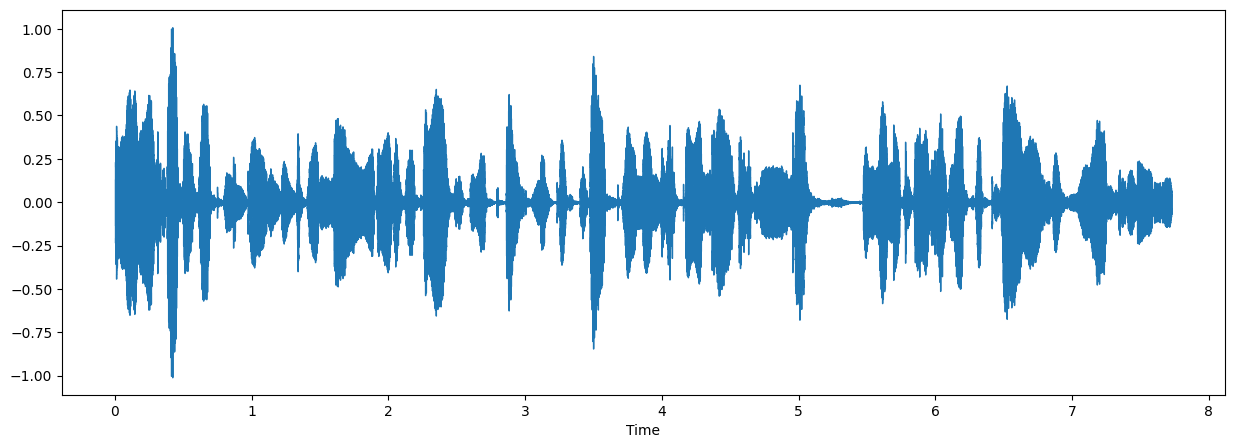

In [35]:
# Visualize waveform of sample audio above
# sr (sample rate) refers to the frequency of "snapshots" of the audio used for digital representation
audio_data, sample_rate = librosa.load(random_audio_file)
plt.figure(figsize=(15, 5))
librosa.display.waveshow(audio_data, sr=sample_rate)

In [36]:
# Convert audio file to spectrogram
# def create_spectrogram(file_path):
#     audio_data, sample_rate = librosa.load(file_path)
#     spectrogram = librosa.stft(audio_data)
#     decibel_spectrogram = librosa.amplitude_to_db(abs(spectrogram))
#     return decibel_spectrogram

# Convert audio file to mel-scale spectrogram
# See https://medium.com/analytics-vidhya/understanding-the-mel-spectrogram-fca2afa2ce53
def create_mel_spectrogram(file_path):
    audio_data, sample_rate = librosa.load(file_path)  
    # Convert audio to mel-based spectrogram
    mel_spectrogram = librosa.feature.melspectrogram(y=audio_data, sr=sample_rate)
    # Convert from amplitude squared to decibel units
    mel_decibel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)  
    return mel_decibel_spectrogram

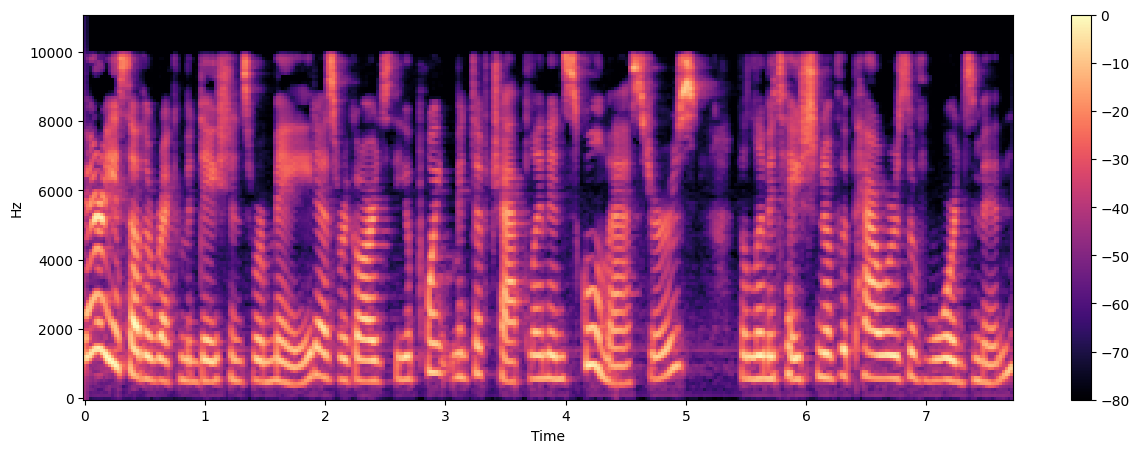

In [37]:
# Spectrogram representation of the sample wave form above
sample_spectrogram = create_mel_spectrogram(random_audio_file)
plt.figure(figsize=(15, 5))
librosa.display.specshow(sample_spectrogram, x_axis='time', y_axis='hz')
plt.colorbar()

In [40]:
from tqdm import tqdm

# Resize spectrogram to a fixed shape (128, 87) to make sure they are homogeneous
def resize_spectrogram(spectrogram, target_shape=(128, 87)):
    # Resize the spectrogram to the target shape
    return np.resize(spectrogram, target_shape)

# Use spectrograms as features to train the model
def get_features_and_labels(real_audio_files, fake_audio_files):
    spec_arr = []
    labels = []
    
    # Loop over real audio files with a progress bar
    for file in tqdm(real_audio_files, desc="Processing real audio files", unit="file"):
        spectrogram = create_mel_spectrogram(file)
        spectrogram_resized = resize_spectrogram(spectrogram)
        spec_arr.append(spectrogram_resized)
        labels.append(0)
    
    # Loop over fake audio files with a progress bar
    for file in tqdm(fake_audio_files, desc="Processing fake audio files", unit="file"):
        spectrogram = create_mel_spectrogram(file)
        spectrogram_resized = resize_spectrogram(spectrogram)
        spec_arr.append(spectrogram_resized)
        labels.append(1)
    
    return np.array(spec_arr), np.array(labels)

# Now use the function as before
train_features, train_labels = get_features_and_labels(train_real_audio, train_fake_audio)
validation_features, validation_labels = get_features_and_labels(validation_real_audio, validation_fake_audio)
test_features, test_labels = get_features_and_labels(test_real_audio, test_fake_audio)

Processing fake audio files: 100%|██████████| 2370/2370 [00:50<00:00, 47.03file/s]


In [41]:
import numpy as np

# Save features and labels in compressed .npz format
def save_features_and_labels_compressed(features, labels, filename):
    np.savez_compressed(filename, features=features, labels=labels)
    print(f"Features and labels saved to {filename}")

# File paths where the features and labels will be saved in compressed format
train_file = "train_features_labels.npz"
validation_file = "validation_features_labels.npz"
test_file = "test_features_labels.npz"

# Save the features and labels for train, validation, and test sets in compressed .npz files
save_features_and_labels_compressed(train_features, train_labels, train_file)
save_features_and_labels_compressed(validation_features, validation_labels, validation_file)
save_features_and_labels_compressed(test_features, test_labels, test_file)

Features and labels saved to train_features_labels.npz
Features and labels saved to validation_features_labels.npz
Features and labels saved to test_features_labels.npz


In [42]:
# Load the saved compressed features and labels
def load_features_and_labels_compressed(filename):
    data = np.load(filename)
    features = data['features']
    labels = data['labels']
    print(f"Loaded features and labels from {filename}")
    return features, labels

# Example of loading saved compressed features and labels
train_features, train_labels = load_features_and_labels_compressed(train_file)
validation_features, validation_labels = load_features_and_labels_compressed(validation_file)
test_features, test_labels = load_features_and_labels_compressed(test_file)

Loaded features and labels from train_features_labels.npz
Loaded features and labels from validation_features_labels.npz
Loaded features and labels from test_features_labels.npz


In [43]:
# we've essentially converted audio into images for machine learning

In [44]:
print("train features shape: {}".format(train_features.shape))
print("test features shape: {}".format(test_features.shape))

train features shape: (53868, 128, 87)
test features shape: (4634, 128, 87)


In [72]:
# Significantly trimmed VGG model to optimize results

trimmed_vgg = Sequential()
trimmed_vgg.add(Reshape((128, 87, 1),input_shape=train_features.shape[1:]))

trimmed_vgg.add(Conv2D(filters=64, kernel_size=(3,3), padding="same", activation='relu'))
trimmed_vgg.add(Conv2D(filters=64, kernel_size=(3,3), padding="same", activation='relu'))
trimmed_vgg.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

trimmed_vgg.add(Conv2D(filters=128, kernel_size=(3,3), padding="same", activation='relu'))
trimmed_vgg.add(Conv2D(filters=128, kernel_size=(3,3), padding="same", activation='relu'))
trimmed_vgg.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

trimmed_vgg.add(Flatten())
trimmed_vgg.add(Dense(units=256,activation="relu"))
trimmed_vgg.add(Dense(units=256,activation="relu"))
trimmed_vgg.add(Dense(1, activation="sigmoid"))

trimmed_vgg.summary()

/opt/conda/lib/python3.10/site-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_4 (Reshape)             │ (None, 128, 87, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 128, 87, 64)    │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 128, 87, 64)    │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 64, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 64, 43, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 64, 43, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 21, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 86016)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │    22,020,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,345,409 (85.24 MB)

 Trainable params: 22,345,409 (85.24 MB)

 Non-trainable params: 0 (0.00 B)

In [73]:
# Compile model
# Adam optimiser helps model get unstuck when stuck at local minima
trimmed_vgg.compile(optimizer=keras.optimizers.Adam(),
                    loss=keras.losses.binary_crossentropy, 
                    metrics=["accuracy"])

In [74]:
simple_vgg_history = trimmed_vgg.fit(train_features,
                                      train_labels,
                                      validation_data = [validation_features, validation_labels],
                                      batch_size = 32,
                                      epochs = 10,
                                      steps_per_epoch = 300)

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 24s 71ms/step - accuracy: 0.6630 - loss: 3.2384 - val_accuracy: 0.7883 - val_loss: 0.4496
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 20s 67ms/step - accuracy: 0.8165 - loss: 0.4006 - val_accuracy: 0.7976 - val_loss: 0.4062
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 19s 65ms/step - accuracy: 0.8307 - loss: 0.3669 - val_accuracy: 0.8247 - val_loss: 0.3839
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 19s 64ms/step - accuracy: 0.8298 - loss: 0.3751 - val_accuracy: 0.8348 - val_loss: 0.3604
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 19s 64ms/step - accuracy: 0.8380 - loss: 0.3613 - val_accuracy: 0.8544 - val_loss: 0.3306
Epoch 6/10
184/300 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.8371 - loss: 0.3577

/opt/conda/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


300/300 ━━━━━━━━━━━━━━━━━━━━ 14s 48ms/step - accuracy: 0.8349 - loss: 0.3618 - val_accuracy: 0.8517 - val_loss: 0.3440
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.8608 - loss: 0.3231 - val_accuracy: 0.8599 - val_loss: 0.3345
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 19s 65ms/step - accuracy: 0.8732 - loss: 0.2883 - val_accuracy: 0.8889 - val_loss: 0.2730
Epoch 9/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 19s 65ms/step - accuracy: 0.8801 - loss: 0.2802 - val_accuracy: 0.8509 - val_loss: 0.3359
Epoch 10/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.8966 - loss: 0.2472 - val_accuracy: 0.9125 - val_loss: 0.2265


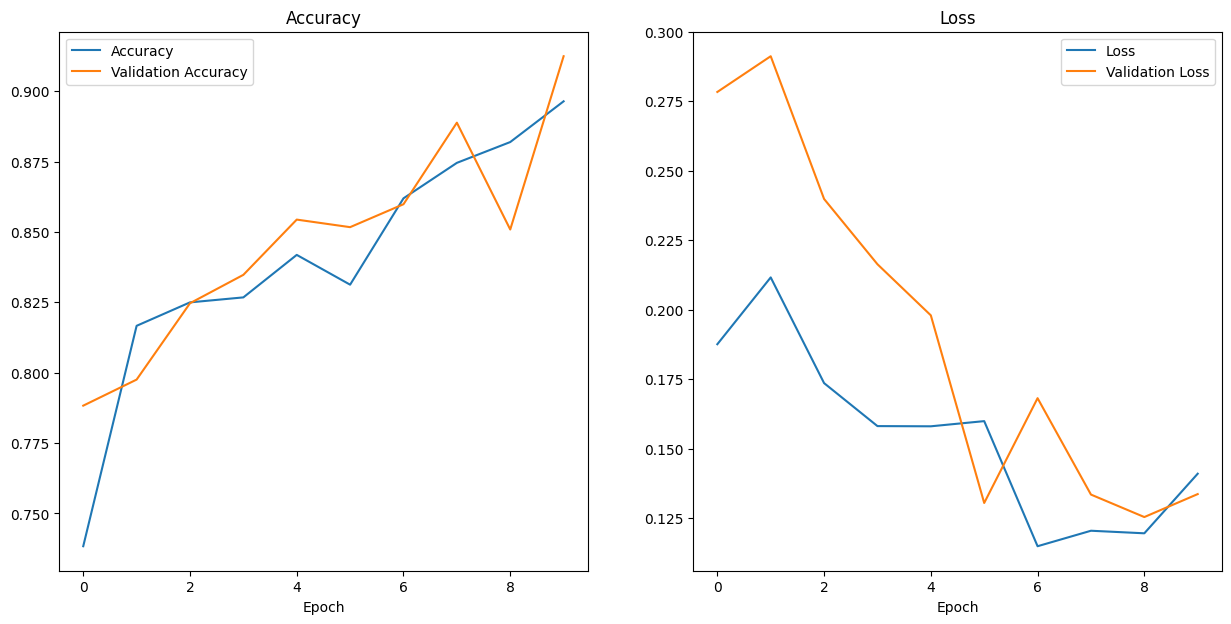

In [75]:
# Note that extremely high accuracy is not due to model overfitting,
# it's because the dataset is very "easy" relative to actual modern state of deepfaked audio
# i.e. the fakes are mostly easily detectable, even to the human ear

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

ax1.plot(simple_vgg_history.history["accuracy"])
ax1.plot(simple_vgg_history.history['val_accuracy'])
ax1.set_title("Accuracy")
ax1.set_xlabel("Epoch")
ax1.legend(["Accuracy","Validation Accuracy"])

ax2.plot(trimmed_vgg_history.history["loss"])
ax2.plot(trimmed_vgg_history.history["val_loss"])
ax2.set_title("Loss")
ax2.set_xlabel("Epoch")
ax2.legend(["Loss","Validation Loss"])

plt.show()

In [76]:
# Test Data Results

trimmed_vgg_loss, trimmed_vgg_accuracy = trimmed_vgg.evaluate(test_features, test_labels)

145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.7528 - loss: 0.5423


In [77]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set
test_predictions = (trimmed_vgg.predict(test_features) > 0.5).astype("int32")

# Compute Precision, Recall, F1 Score
precision = precision_score(test_labels, test_predictions)
recall = recall_score(test_labels, test_predictions)
f1 = f1_score(test_labels, test_predictions)

# Print the metrics
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step
Precision: 0.7645
Recall: 0.7781
F1 Score: 0.7712


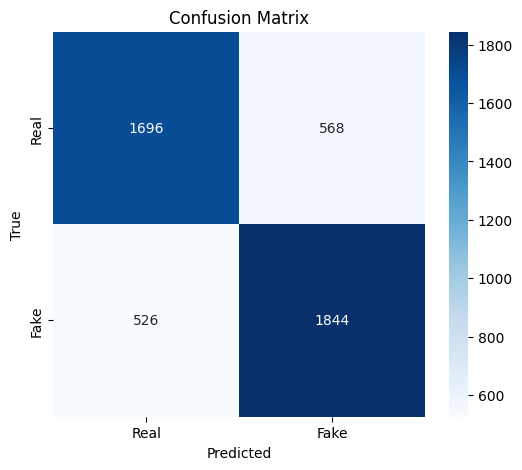

In [78]:
# Compute Confusion Matrix
cm = confusion_matrix(test_labels, test_predictions)

# Plot Confusion Matrix using Seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Real", "Fake"], yticklabels=["Real", "Fake"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step


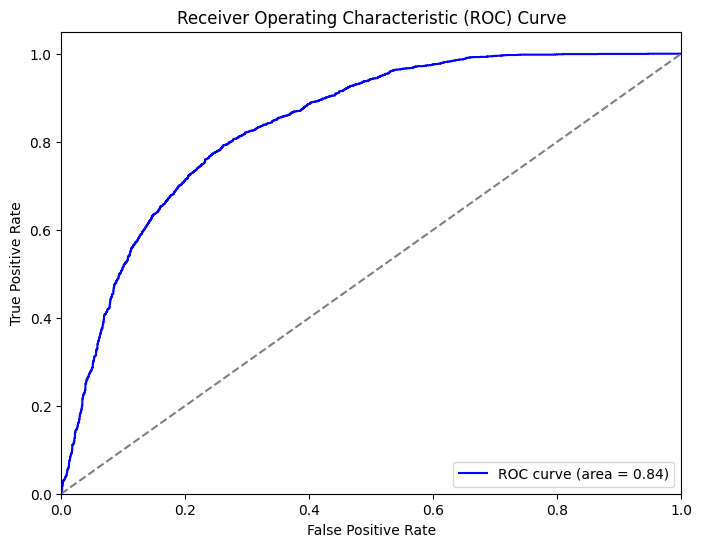

In [79]:
fpr, tpr, thresholds = roc_curve(test_labels, trimmed_vgg.predict(test_features))
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='b', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

In [80]:
# Saving the final version

trimmed_vgg.save('deepfake_audio_detector.h5')